# Correlação entre Variáveis
### Pearson e Spearman — Teoria e Ilustração

---

Correlação mede o **grau e a direção da relação** entre duas variáveis. Não confunda com causalidade — correlação apenas descreve uma associação observada nos dados, sem implicar que uma variável *causa* a outra.

Este notebook cobre:

1. **Intuição e conceitos fundamentais**
2. **Correlação de Pearson** — relações lineares
3. **Correlação de Spearman** — relações monotônicas (baseada em ranks)
4. **Quando usar cada uma** — limitações e armadilhas
5. **O Quarteto de Anscombe** — por que nunca confie só no número

---
## 0. Imports

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.size': 11,
})

np.random.seed(42)
print('✅ Imports OK')

✅ Imports OK


---
# Parte 1 — Intuição Fundamental

## O que é Correlação?

Dado um conjunto de pares de observações $(X, Y)$, queremos saber: **quando $X$ aumenta, o que tende a acontecer com $Y$?**

O coeficiente de correlação $r$ resume essa relação em um único número no intervalo $[-1, +1]$:

| Valor de $r$ | Interpretação |
|---|---|
| $r = +1$ | Relação positiva **perfeita** — $X \uparrow$ implica $Y \uparrow$ sem exceções |
| $0 < r < 1$ | Tendência positiva — quanto maior $r$, mais forte a relação |
| $r = 0$ | Nenhuma relação **linear** (pode existir relação de outro tipo!) |
| $-1 < r < 0$ | Tendência negativa — $X \uparrow$ tende a implicar $Y \downarrow$ |
| $r = -1$ | Relação negativa **perfeita** |

> ⚠️ **Atenção:** $r = 0$ **não significa independência**. Significa apenas ausência de relação *linear*. Uma relação quadrática perfeita pode ter $r = 0$.

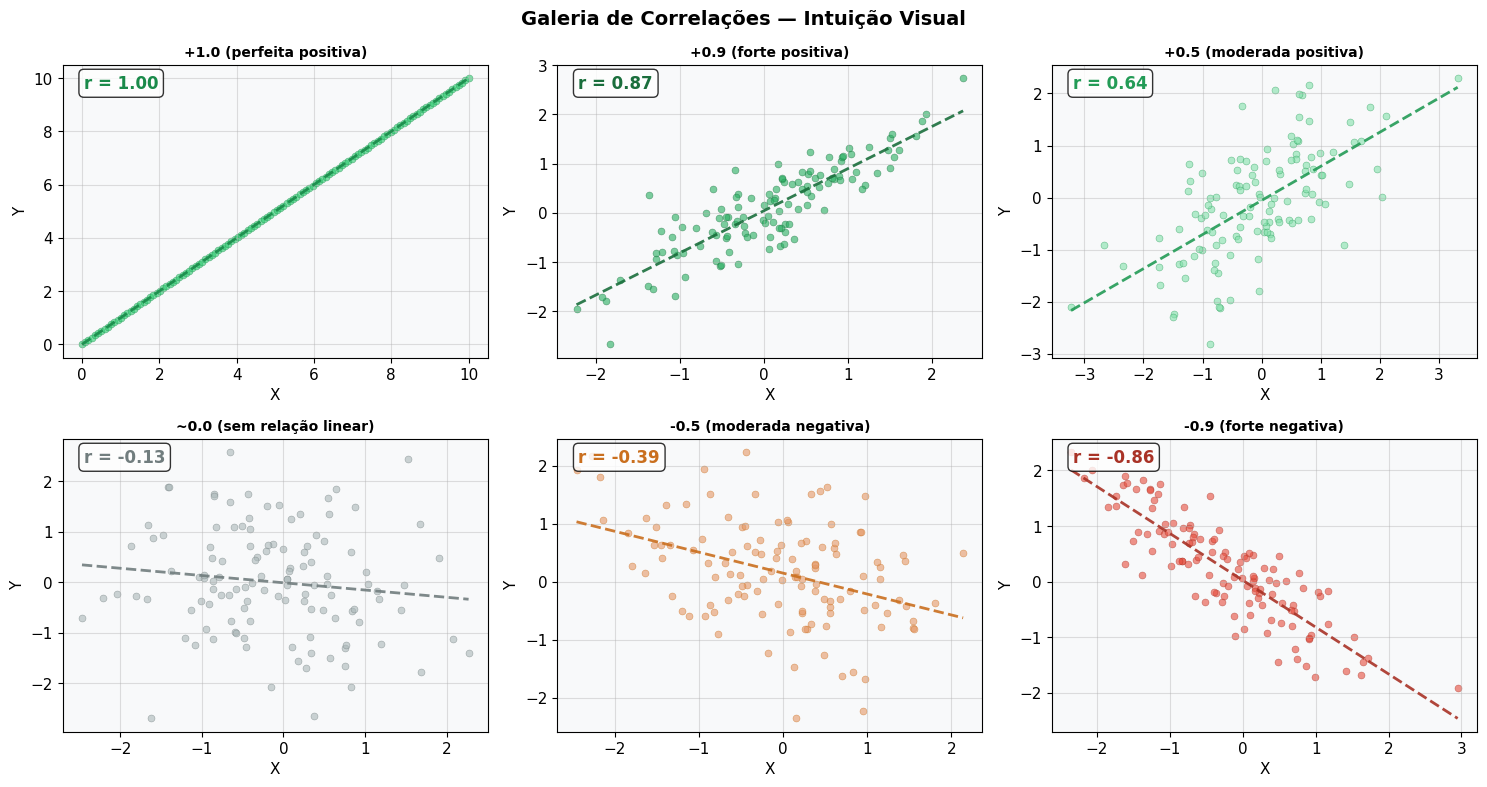

In [24]:
# Galeria de correlações para intuição visual
n = 120
cenarios = [
    ('+1.0 (perfeita positiva)', lambda: (np.linspace(0,10,n), np.linspace(0,10,n))),
    ('+0.9 (forte positiva)',    lambda: stats.multivariate_normal.rvs([0,0], [[1,0.9],[0.9,1]], n).T),
    ('+0.5 (moderada positiva)', lambda: stats.multivariate_normal.rvs([0,0], [[1,0.5],[0.5,1]], n).T),
    ('~0.0 (sem relação linear)',lambda: (np.random.randn(n), np.random.randn(n))),
    ('-0.5 (moderada negativa)', lambda: stats.multivariate_normal.rvs([0,0], [[1,-0.5],[-0.5,1]], n).T),
    ('-0.9 (forte negativa)',    lambda: stats.multivariate_normal.rvs([0,0], [[1,-0.9],[-0.9,1]], n).T),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Galeria de Correlações — Intuição Visual', fontsize=14, fontweight='bold')
CORES = [('#2ecc71','#1a8a4a'), ('#27ae60','#1a6e3c'), ('#82e0aa','#239b56'),
         ('#aab7b8','#717d7e'), ('#e59866','#ca6f1e'), ('#e74c3c','#a93226')]

for ax, (titulo, gen), (c1, c2) in zip(axes.flat, cenarios, CORES):
    x, y = gen()
    r, p = stats.pearsonr(x, y)
    ax.scatter(x, y, alpha=0.6, color=c1, s=25, edgecolors=c2, linewidth=0.4)
    # Linha de tendência
    if abs(r) > 0.05:
        m, b = np.polyfit(x, y, 1)
        xr = np.linspace(x.min(), x.max(), 100)
        ax.plot(xr, m*xr+b, color=c2, linewidth=2, linestyle='--', alpha=0.9)
    ax.set_title(titulo, fontweight='bold', fontsize=10)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.text(0.05, 0.92, f'r = {r:.2f}', transform=ax.transAxes,
            fontsize=12, fontweight='bold', color=c2,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

---
# Parte 2 — Correlação de Pearson

## Definição

A correlação de Pearson mede o grau de **relação linear** entre duas variáveis contínuas. É definida como a **covariância normalizada** entre $X$ e $Y$:

$$r_{XY} = \frac{\text{Cov}(X, Y)}{\sigma_X \cdot \sigma_Y} = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^{n}(x_i - \bar{x})^2} \cdot \sqrt{\sum_{i=1}^{n}(y_i - \bar{y})^2}}$$

## Decompondo a Fórmula

O **numerador** é a covariância: $(x_i - \bar{x})(y_i - \bar{y})$. Para cada par de pontos, calcula o produto dos desvios em relação às médias.
- Se $x_i > \bar{x}$ e $y_i > \bar{y}$ simultaneamente → produto **positivo** (relação positiva)
- Se $x_i > \bar{x}$ e $y_i < \bar{y}$ simultaneamente → produto **negativo** (relação negativa)

O **denominador** é o produto dos desvios-padrão, que serve para **normalizar** o resultado para $[-1, +1]$, tornando-o independente da escala das variáveis.

## Pressupostos

| Pressuposto | Detalhe |
|---|---|
| **Linearidade** | A relação entre $X$ e $Y$ deve ser linear |
| **Normalidade** | Idealmente, ambas as variáveis seguem distribuição normal |
| **Sem outliers extremos** | Outliers distorcem severamente o valor de $r$ |
| **Escala intervalar ou racional** | As variáveis devem ser contínuas e mensuráveis |

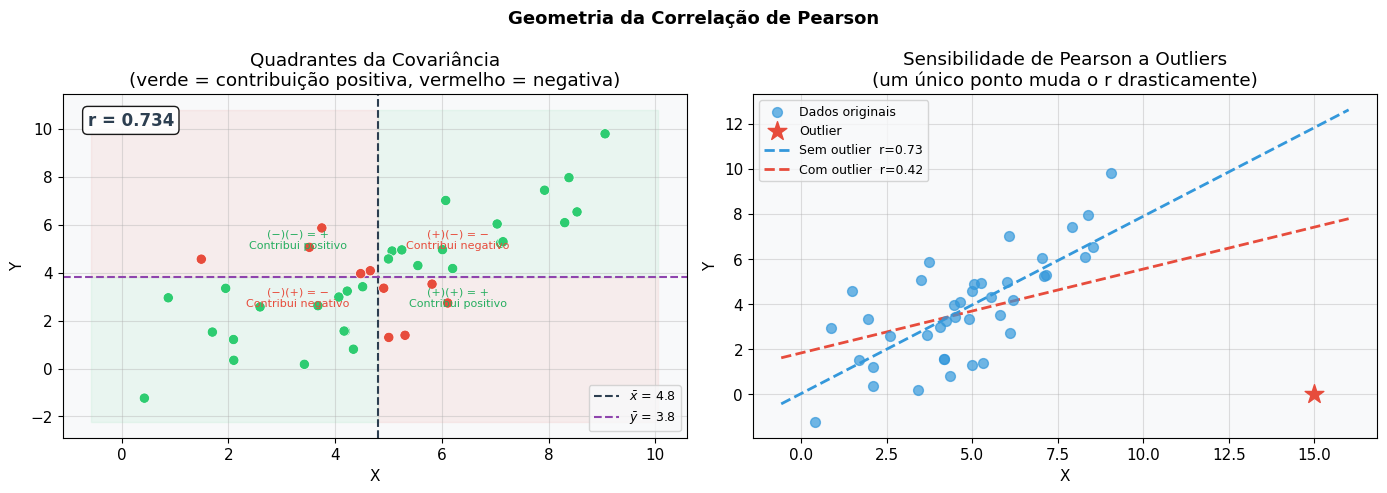

In [25]:
# Visualizando a geometria da covariância (quadrantes)
np.random.seed(7)
x = np.random.randn(40) * 2 + 5
y = 0.8 * x + np.random.randn(40) * 1.5

xm, ym = x.mean(), y.mean()
produto = (x - xm) * (y - ym)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Geometria da Correlação de Pearson', fontsize=13, fontweight='bold')

# Plot 1: quadrantes da covariância
ax = axes[0]
cores_pts = ['#2ecc71' if p > 0 else '#e74c3c' for p in produto]
ax.scatter(x, y, c=cores_pts, s=55, edgecolors='white', linewidth=0.5, zorder=3)
ax.axvline(xm, color='#2c3e50', linewidth=1.5, linestyle='--', label=f'$\\bar{{x}}$ = {xm:.1f}')
ax.axhline(ym, color='#8e44ad', linewidth=1.5, linestyle='--', label=f'$\\bar{{y}}$ = {ym:.1f}')

# Sombreando os quadrantes
xlim, ylim = ax.get_xlim() or (x.min()-1, x.max()+1), ax.get_ylim() or (y.min()-1, y.max()+1)
ax.fill_between([x.min()-1, xm], ym, y.max()+1, alpha=0.07, color='#e74c3c')
ax.fill_between([xm, x.max()+1], y.min()-1, ym,  alpha=0.07, color='#e74c3c')
ax.fill_between([x.min()-1, xm], y.min()-1, ym,  alpha=0.07, color='#2ecc71')
ax.fill_between([xm, x.max()+1], ym, y.max()+1,  alpha=0.07, color='#2ecc71')

r, _ = stats.pearsonr(x, y)
ax.text(0.04, 0.95, f'r = {r:.3f}', transform=ax.transAxes, fontsize=12, fontweight='bold',
        color='#2c3e50', va='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

# Anotações dos quadrantes
ax.text(xm - 1.5, ym + 1.2, '(−)(−) = +\nContribui positivo', fontsize=8, color='#27ae60', ha='center')
ax.text(xm + 1.5, ym - 1.2, '(+)(+) = +\nContribui positivo', fontsize=8, color='#27ae60', ha='center')
ax.text(xm + 1.5, ym + 1.2, '(+)(−) = −\nContribui negativo', fontsize=8, color='#e74c3c', ha='center')
ax.text(xm - 1.5, ym - 1.2, '(−)(+) = −\nContribui negativo', fontsize=8, color='#e74c3c', ha='center')

from matplotlib.patches import Patch
ax.legend(fontsize=9)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Quadrantes da Covariância\n(verde = contribuição positiva, vermelho = negativa)')

# Plot 2: Efeito devastador de um outlier
ax2 = axes[1]
x2 = x.copy(); y2 = y.copy()
r_sem, _ = stats.pearsonr(x2, y2)

# Adicionando um único outlier
x_out = np.append(x2, 15)
y_out = np.append(y2, 0)
r_com, _ = stats.pearsonr(x_out, y_out)

ax2.scatter(x2, y2, color='#3498db', s=50, label='Dados originais', alpha=0.7, zorder=3)
ax2.scatter([15], [0], color='#e74c3c', s=200, marker='*', label='Outlier', zorder=4)

m1, b1 = np.polyfit(x2, y2, 1)
m2, b2 = np.polyfit(x_out, y_out, 1)
xr = np.linspace(x.min()-1, 16, 100)
ax2.plot(xr, m1*xr+b1, color='#3498db', linewidth=2, linestyle='--', label=f'Sem outlier  r={r_sem:.2f}')
ax2.plot(xr, m2*xr+b2, color='#e74c3c', linewidth=2, linestyle='--', label=f'Com outlier  r={r_com:.2f}')

ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_title('Sensibilidade de Pearson a Outliers\n(um único ponto muda o r drasticamente)')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

In [26]:
# Calculando Pearson do zero (sem scipy) para desmistificar
np.random.seed(0)
X = np.array([2, 4, 5, 7, 8, 10, 11, 13])
Y = np.array([3, 5, 4, 8, 9,  9, 11, 14])

xm, ym = X.mean(), Y.mean()
num    = np.sum((X - xm) * (Y - ym))
den    = np.sqrt(np.sum((X - xm)**2)) * np.sqrt(np.sum((Y - ym)**2))
r_manual = num / den

r_scipy, p_valor = stats.pearsonr(X, Y)

print("Cálculo Manual da Correlação de Pearson")
print("=" * 45)
print(f"X:       {X}")
print(f"Y:       {Y}")
print(f"Média X: {xm:.2f}  |  Média Y: {ym:.2f}")
print(f"")
print(f"Numerador   (Cov bruta)  = Σ(xi−x̄)(yi−ȳ) = {num:.2f}")
print(f"Denominador (normaliz.)  = σX × σY         = {den:.2f}")
print(f"")
print(f"r (manual)   = {num:.2f} / {den:.2f} = {r_manual:.4f}")
print(f"r (scipy)    = {r_scipy:.4f}")

Cálculo Manual da Correlação de Pearson
X:       [ 2  4  5  7  8 10 11 13]
Y:       [ 3  5  4  8  9  9 11 14]
Média X: 7.50  |  Média Y: 7.88

Numerador   (Cov bruta)  = Σ(xi−x̄)(yi−ȳ) = 94.50
Denominador (normaliz.)  = σX × σY         = 97.44

r (manual)   = 94.50 / 97.44 = 0.9699
r (scipy)    = 0.9699


---
# Parte 3 — Correlação de Spearman

## Motivação

A correlação de Pearson exige que a relação seja **linear**. Mas e quando a relação existe, é consistente (monotônica), mas não segue uma reta? Ou quando os dados têm outliers severos? Ou quando as variáveis são ordinais?

Nesses casos, usamos a **correlação de Spearman**.

## A Ideia: Trabalhar com Ranks

Em vez de usar os valores brutos de $X$ e $Y$, o Spearman **substitui cada valor pela sua posição (rank) na lista ordenada** e então aplica a fórmula de Pearson sobre esses ranks.

$$r_s = r_{\text{Pearson}}(\text{rank}(X),\ \text{rank}(Y))$$

Essa transformação tem duas consequências poderosas:
- **Robustez a outliers:** Um valor extremo vira apenas "o maior" — seu rank — e não distorce mais o resultado
- **Captura relações monotônicas:** Detecta qualquer relação onde $Y$ sempre cresce (ou sempre decresce) com $X$, mesmo que não linearmente

## O que é uma Relação Monotônica?

Uma função é **monotônica** quando preserva a ordem: à medida que $X$ aumenta, $Y$ só cresce (monotônica crescente) ou só decresce (monotônica decrescente) — sem nunca "voltar atrás".

Toda relação linear é monotônica, mas o inverso não é verdade: $Y = X^3$, $Y = e^X$, $Y = \log(X)$ são todas monotônicas mas não lineares.

In [27]:
# Demonstrando a transformação de ranks
X = np.array([3, 1, 8, 5, 2, 7, 4, 6])
Y = np.array([12, 5, 30, 18, 8, 25, 14, 22])

rank_X = stats.rankdata(X)
rank_Y = stats.rankdata(Y)
d      = rank_X - rank_Y

df_ranks = pd.DataFrame({
    'X (bruto)':  X,
    'Y (bruto)':  Y,
    'Rank de X':  rank_X.astype(int),
    'Rank de Y':  rank_Y.astype(int),
    'd = rankX - rankY': d.astype(int),
    'd²':         (d**2).astype(int),
})

print("Transformação de Valores Brutos em Ranks")
print("=" * 58)
print(df_ranks.to_string(index=False))

n = len(X)
soma_d2 = (d**2).sum()
rs_formula = 1 - (6 * soma_d2) / (n * (n**2 - 1))
rs_scipy, _ = stats.spearmanr(X, Y)
rp_scipy, _ = stats.pearsonr(X, Y)

print(f"\nΣd² = {soma_d2}")
print(f"n = {n}")
print(f"\nrs = 1 - 6×{soma_d2} / ({n}×({n}²-1)) = {rs_formula:.4f}")
print(f"rs (scipy)    = {rs_scipy:.4f}")
print(f"rp (Pearson)  = {rp_scipy:.4f}  ← neste caso, relação linear, então similar")

Transformação de Valores Brutos em Ranks
 X (bruto)  Y (bruto)  Rank de X  Rank de Y  d = rankX - rankY  d²
         3         12          3          3                  0   0
         1          5          1          1                  0   0
         8         30          8          8                  0   0
         5         18          5          5                  0   0
         2          8          2          2                  0   0
         7         25          7          7                  0   0
         4         14          4          4                  0   0
         6         22          6          6                  0   0

Σd² = 0.0
n = 8

rs = 1 - 6×0.0 / (8×(8²-1)) = 1.0000
rs (scipy)    = 1.0000
rp (Pearson)  = 0.9971  ← neste caso, relação linear, então similar


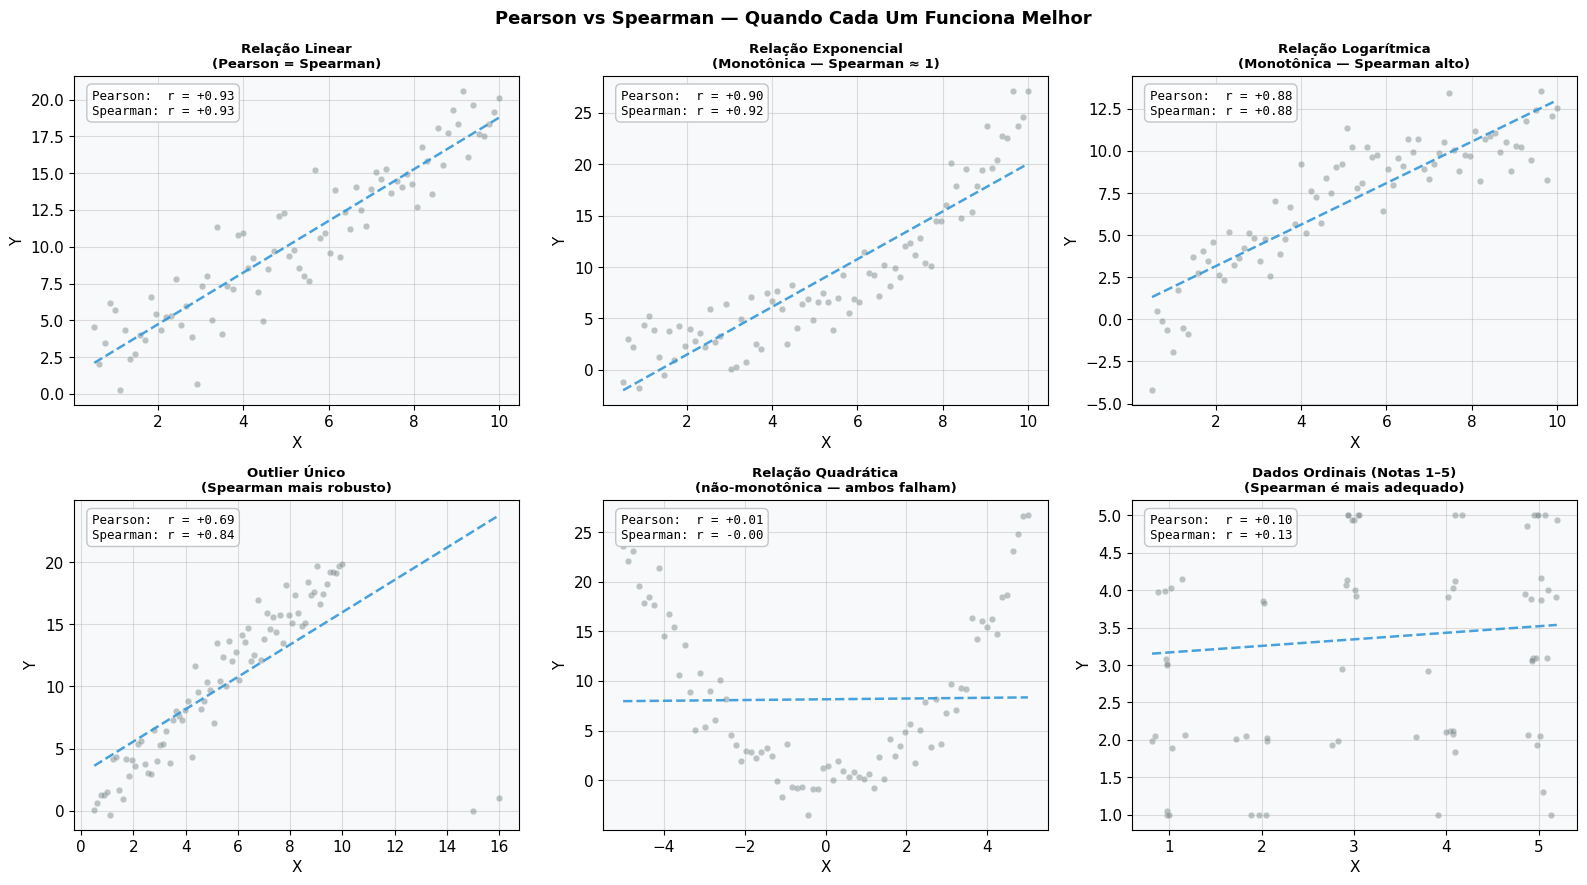

In [28]:
# Spearman captura relações não-lineares que Pearson perde
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Pearson vs Spearman — Quando Cada Um Funciona Melhor', fontsize=13, fontweight='bold')

n = 80
x = np.linspace(0.5, 10, n)

cenarios = [
    ('Relação Linear\n(Pearson = Spearman)',
     x, 2*x + np.random.randn(n)*2),
    ('Relação Exponencial\n(Monotônica — Spearman ≈ 1)',
     x, np.exp(x/3) + np.random.randn(n)*2),
    ('Relação Logarítmica\n(Monotônica — Spearman alto)',
     x, 5*np.log(x) + np.random.randn(n)*1.5),
    ('Outlier Único\n(Spearman mais robusto)',
     np.append(x, [15, 16]), np.append(2*x + np.random.randn(n)*1.5, [0, 1])),
    ('Relação Quadrática\n(não-monotônica — ambos falham)',
     np.linspace(-5,5,n), (np.linspace(-5,5,n))**2 + np.random.randn(n)*2),
    ('Dados Ordinais (Notas 1–5)\n(Spearman é mais adequado)',
     np.random.randint(1,6,n).astype(float) + np.random.randn(n)*0.1,
     np.clip(np.random.randint(1,6,n).astype(float) + np.random.randint(0,2,n) + np.random.randn(n)*0.1, 1, 5)),
]

for ax, (titulo, xi, yi) in zip(axes.flat, cenarios):
    rp, _ = stats.pearsonr(xi, yi)
    rs, _ = stats.spearmanr(xi, yi)

    cor_p = '#3498db'
    cor_s = '#e74c3c'
    ax.scatter(xi, yi, alpha=0.5, color='#7f8c8d', s=22, edgecolors='white', linewidth=0.3, zorder=2)

    # linha de tendência linear
    m, b = np.polyfit(xi, yi, 1)
    xr = np.linspace(xi.min(), xi.max(), 100)
    ax.plot(xr, m*xr+b, color=cor_p, linewidth=1.8, linestyle='--', alpha=0.9, label='Tendência linear')

    ax.set_title(titulo, fontsize=9.5, fontweight='bold')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')

    # Caixa de métricas
    txt = f'Pearson:  r = {rp:+.2f}\nSpearman: r = {rs:+.2f}'
    ax.text(0.04, 0.96, txt, transform=ax.transAxes, fontsize=9, va='top',
            fontfamily='monospace',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#bdc3c7', alpha=0.95))

plt.tight_layout()
plt.show()

---
# Parte 4 — Quando Usar Cada Um?

## Tabela Comparativa

| Critério | Pearson | Spearman |
|---|---|---|
| **Tipo de relação** | Linear | Monotônica (qualquer forma) |
| **Tipo de dados** | Contínuos, intervalar/racional | Contínuos, ordinais ou com outliers |
| **Sensibilidade a outliers** | Alta — outliers distorcem muito | Baixa — outliers viram apenas rank extremo |
| **Pressuposto de normalidade** | Sim (para inferência) | Não |
| **Interpretação** | Quanto % da variância é linear | Concordância de ordem (ranking) |
| **Relação quadrática ($y=x^2$)** | Pode ser ≈ 0 mesmo com relação forte | Também pode ser ≈ 0 (não-monotônica!) |

## Regra Prática de Decisão

```sh
A relação parece linear no scatter plot?  
  Sim → Pearson  
  Não → A relação é monotônica (só sobe ou só desce)?  
          Sim → Spearman  
          Não → Nenhuma das duas capta bem. Considere outras abordagens.

Há outliers evidentes?  
  Sim → Prefira Spearman (mais robusto)

Variáveis são ordinais (ex: notas, rankings, escalas Likert)?  
  Sim → Spearman é mais adequado semanticamente
```